(C) Copyright 2025 - ECMWF and individual contributors.

This software is licensed under the terms of the Apache Licence Version 2.0
which can be obtained at http://www.apache.org/licenses/LICENSE-2.0.
In applying this licence, ECMWF does not waive the privileges and immunities
granted to it by virtue of its status as an intergovernmental organisation nor
does it submit to any jurisdiction.

<!-- <div style="border: 2px solid #9fc4ae; border-radius: 8px; padding: 8px; background-color: #f8fdf9;">
<!-- <h2>🗂️ <strong>Training Dataset Summary</strong></h2> -->
<!-- </div> -->

To evaluate and compare multiple machine learning strategies, we tested several model configurations, including gradient-boosted decision trees, random forests, and neural networks.  
Among these, the **XGBoost-based approach** demonstrated the best overall performance and computational efficiency.  For this reason the  PoF system uses gradient-boosted decision trees that iteratively improve prediction accuracy by correcting errors made in previous iterations.  We found that this method provides an efficient optimization framework for large-scale, global applications. 

The model is trained using a classifier setup, where a positive event is defined as the occurrence of an active fire detection within a grid cell on a given day.  
```{note} 
While tree-based models do not explicitly represent temporal dependencies, this limitation is mitigated through input features that encode environmental memory—such as live fuel moisture, vegetation state, and soil moisture—capturing information about preceding conditions. 
```


Overall, the XGBoost configuration provided the most robust and interpretable results, balancing accuracy, computational cost, and operational suitability.




In [1]:
import pandas as pd
import os
import time
import joblib
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay


Load your data created from the previous notebook


In [2]:

df = pd.read_parquet("./data/training_data.parquet")

print("Loaded data shape:", df.shape)
print("Columns:", list(df.columns))

Loaded data shape: (216233, 14)
Columns: ['AF', 'PR', 'T2', 'RH', 'WS', 'FU_LL', 'FU_LW', 'FU_DF', 'FU_DW', 'DF', 'DW', 'LF', 'PO', 'RD']



Define your features and target

In [3]:
target_col = "AF"
feature_cols = [c for c in df.columns if c not in ["AF"]]

X = df[feature_cols]
y = df[target_col]


```{note}🔀 <strong> Train–Test Split

The dataset is divided into training and testing subsets to evaluate model performance on unseen data.  
We use an **80/20 split**, meaning 80% of the samples are used for training and 20% are reserved for testing.  

To ensure reproducibility, the split is controlled by a fixed random seed (`random_state=42`).  
Additionally, **stratification** is applied (`stratify=y`) so that the proportion of active fire and non-fire samples remains consistent across both training and testing subsets.  
This helps maintain balanced class representation and prevents bias during model evaluation.  
```


In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [5]:
min(y_train)

0.0

| Parameter                               | Description                                                                                                                                                                      |
| --------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`objective="binary:logistic"`**       | Specifies that this is a **binary classification** problem. The model outputs probabilities between 0 and 1 using a logistic function.                                           |
| **`tree_method="hist"`**                | Uses the **histogram-based algorithm** to speed up training, especially for large datasets. It groups feature values into discrete bins instead of processing each unique value. |
| **`n_estimators=300`**                  | The number of **boosting rounds (trees)** to build. Higher values can improve accuracy but may increase training time or risk overfitting.                                       |
| **`max_depth=8`**                       | Maximum depth of each decision tree. Deeper trees can model more complex patterns but may overfit the data.                                                                      |
| **`learning_rate=0.1`**                 | Shrinks the contribution of each tree. Lower values make learning slower but more robust; typically balanced with `n_estimators`.                                                |
| **`subsample=0.8`** *(optional)*        | Fraction of the training data used for each tree. Prevents overfitting and increases generalization. Default is `1.0` (use all data).                                            |
| **`colsample_bytree=0.8`** *(optional)* | Fraction of features (columns) randomly sampled for each tree, adding diversity and reducing overfitting.                                                                        |
| **`eval_metric="logloss"`**             | Evaluation metric for binary classification. Measures the model’s prediction accuracy in terms of probability calibration (lower is better).                                     |
| **`random_state=42`** *(optional)*      | Sets the random seed for reproducibility. Ensures consistent results when running the code multiple times.                                                                       |
| **`n_jobs=-1`**                         | Uses **all available CPU cores** for parallel computation, speeding up training.                                                                                                 |


In [6]:

# -----------------------------
# TRAIN CLASSIFIER
# -----------------------------
print("Training XGBoost Binary Classifier...")
start_time = time.time()

model = XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
#    subsample=0.8,
#    colsample_bytree=0.8,
    eval_metric="logloss",
#    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

end_time = time.time()
print(f"✅ Training completed in {end_time - start_time:.2f} seconds")


Training XGBoost Binary Classifier...
✅ Training completed in 0.96 seconds


In [7]:

# -----------------------------
# EVALUATE MODEL
# -----------------------------
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Classification report:
              precision    recall  f1-score   support

         0.0      0.993     1.000     0.996     42933
         1.0      0.429     0.048     0.086       314

    accuracy                          0.993     43247
   macro avg      0.711     0.524     0.541     43247
weighted avg      0.989     0.993     0.990     43247

ROC-AUC: 0.971

Confusion Matrix:
[[42913    20]
 [  299    15]]


<Figure size 600x500 with 0 Axes>

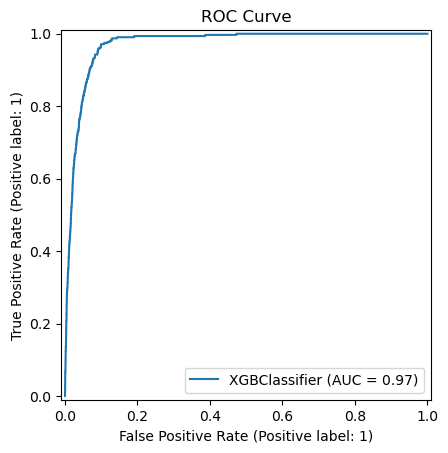

<Figure size 1000x600 with 0 Axes>

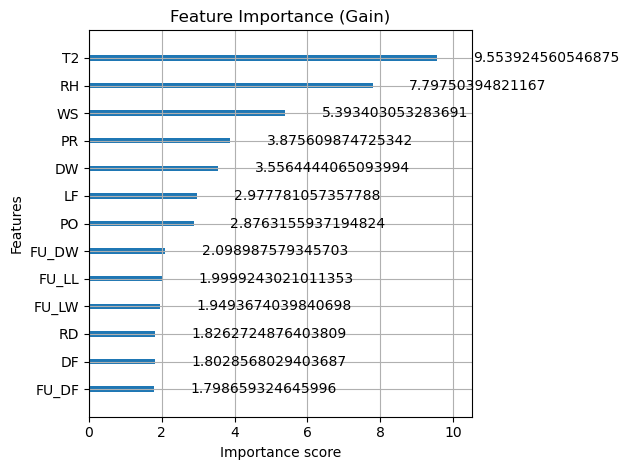

In [8]:

# -----------------------------
# PLOT ROC CURVE & FEATURE IMPORTANCE
# -----------------------------
os.makedirs("./outputs", exist_ok=True)
plt.figure(figsize=(6, 5))
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.savefig("./outputs/POF_ROC.png", dpi=300)
plt.show()
plt.close()

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=20, importance_type="gain")
plt.title("Feature Importance (Gain)")
plt.tight_layout()
plt.savefig("./outputs/POF_importance.png", dpi=300)
plt.show()
plt.close()


In [9]:

# -----------------------------
# SAVE MODEL
# -----------------------------
out_model = "./data/POF_model.joblib"
joblib.dump(model, out_model, compress=3)
print(f"Model saved → {out_model}")

Model saved → ./data/POF_model.joblib
